<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 157.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 151.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 99.0 MB/s eta 0:00:00


Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt

## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [4]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [5]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [6]:
## Write your code here
import pandas as pd

# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Task 1: Identify duplicate rows
duplicate_rows = df.duplicated()  # Boolean Series indicating duplicates
num_duplicates = duplicate_rows.sum()

print(f"\nNumber of duplicate rows in the dataset: {num_duplicates}")

# Display the first few duplicate rows
if num_duplicates > 0:
    print("\nFirst 5 duplicate rows:")
    print(df[duplicate_rows].head())

First 5 rows of the dataset:
   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4    

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [7]:
## Write your code here
import pandas as pd

# Load the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Select key columns to define response patterns
key_columns = ['MainBranch', 'Employment', 'RemoteWork']

# Group by the key columns
grouped = df.groupby(key_columns)

# Count the number of respondents in each pattern
pattern_counts = grouped.size().reset_index(name='NumRespondents')

# Filter patterns that have more than 1 respondent (i.e., repeated patterns)
duplicate_patterns = pattern_counts[pattern_counts['NumRespondents'] > 1]

print(f"\nDuplicate response patterns (more than 1 respondent):")
print(duplicate_patterns.head())

# Analyze other columns that frequently share identical values within these groups
# Take one example group and check other columns
example_pattern = duplicate_patterns.iloc[0][key_columns]
subset = df[(df['MainBranch'] == example_pattern['MainBranch']) &
            (df['Employment'] == example_pattern['Employment']) &
            (df['RemoteWork'] == example_pattern['RemoteWork'])]

print(f"\nColumns frequently shared in this pattern (example group):")
shared_counts = subset.nunique()
print(shared_counts[shared_counts == 1])  # Columns where all values are identical

First 5 rows of the dataset:
   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4    

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


Top shared response patterns:
                       MainBranch                               Employment  \
0  I am a developer by profession                      Employed, full-time   
1  I am a developer by profession                      Employed, full-time   
2  I am a developer by profession                      Employed, full-time   
3  I am a developer by profession  Employed, full-time;Employed, part-time   
4  I am a developer by profession  Employed, full-time;Employed, part-time   

                             RemoteWork  NumRespondents  
0  Hybrid (some remote, some in-person)           15288  
1                             In-person            7118  
2                                Remote           12196  
3  Hybrid (some remote, some in-person)              78  
4                             In-person              25  


/tmp/ipykernel_769/3050618662.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


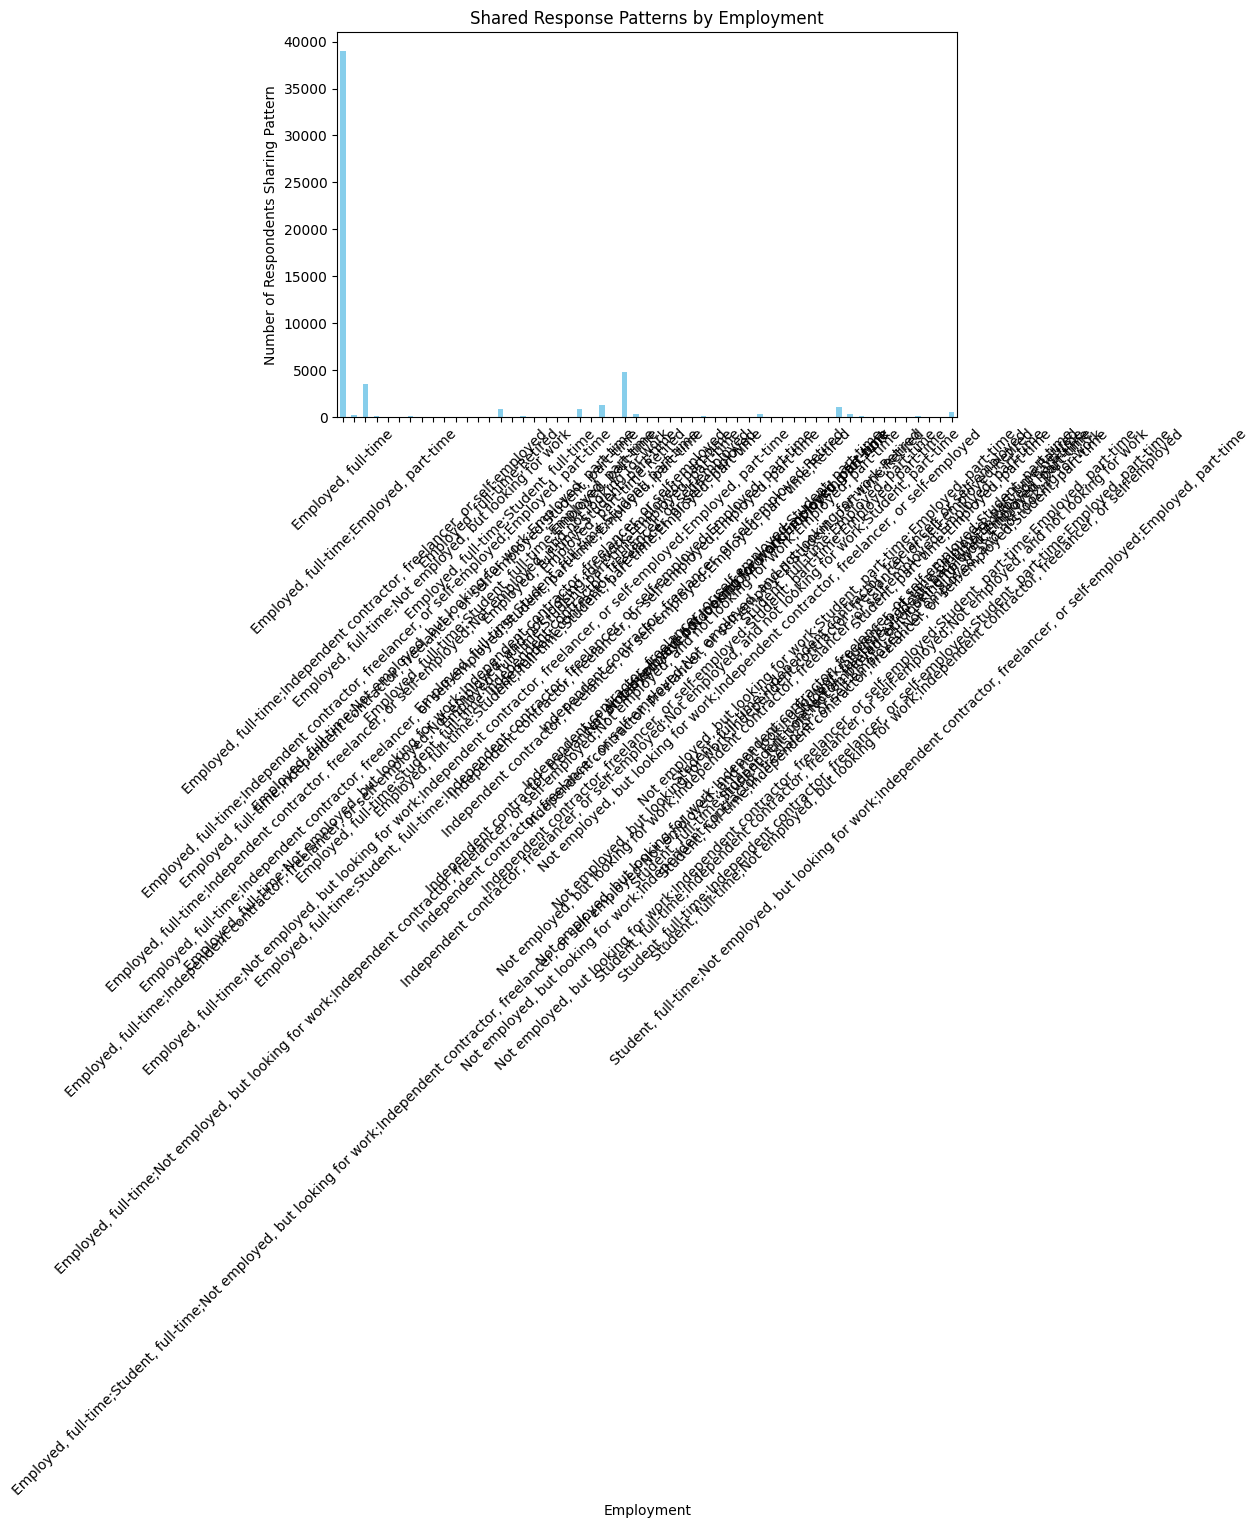

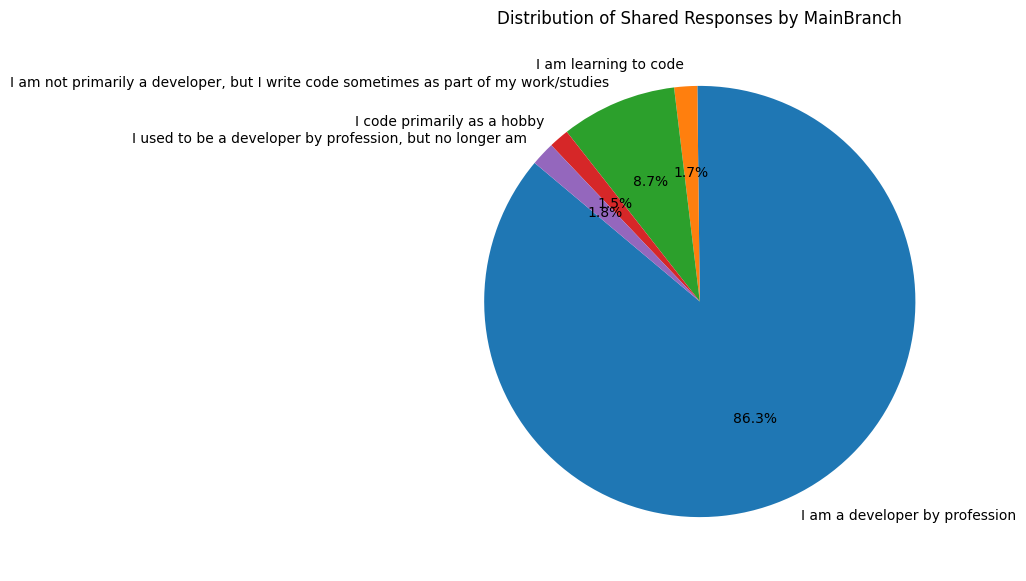

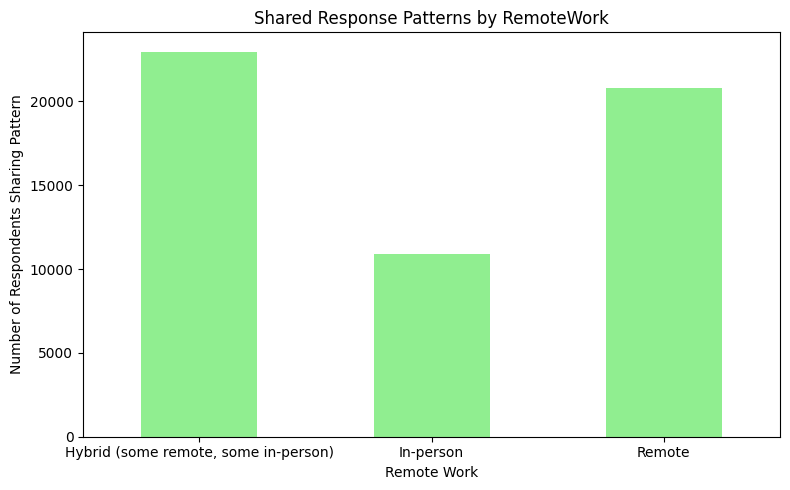

In [8]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Key columns for response patterns
key_columns = ['MainBranch', 'Employment', 'RemoteWork']

# Group by key columns and count respondents
pattern_counts = df.groupby(key_columns).size().reset_index(name='NumRespondents')

# Filter patterns with more than 1 respondent (shared responses)
shared_patterns = pattern_counts[pattern_counts['NumRespondents'] > 1]

print("Top shared response patterns:")
print(shared_patterns.head())

# -----------------------------
# Visualization 1: Bar chart of shared patterns by Employment
# -----------------------------
employment_counts = shared_patterns.groupby('Employment')['NumRespondents'].sum()

plt.figure(figsize=(8,5))
employment_counts.plot(kind='bar', color='skyblue')
plt.title('Shared Response Patterns by Employment')
plt.xlabel('Employment')
plt.ylabel('Number of Respondents Sharing Pattern')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# Visualization 2: Pie chart of shared patterns by MainBranch
# -----------------------------
mainbranch_counts = shared_patterns.groupby('MainBranch')['NumRespondents'].sum()

plt.figure(figsize=(7,7))
mainbranch_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.ylabel('')
plt.title('Distribution of Shared Responses by MainBranch')
plt.show()

# -----------------------------
# Visualization 3: Bar chart of shared patterns by RemoteWork
# -----------------------------
remotework_counts = shared_patterns.groupby('RemoteWork')['NumRespondents'].sum()

plt.figure(figsize=(8,5))
remotework_counts.plot(kind='bar', color='lightgreen')
plt.title('Shared Response Patterns by RemoteWork')
plt.xlabel('Remote Work')
plt.ylabel('Number of Respondents Sharing Pattern')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.



Assessment of removing duplicates based on subset of columns

Removing rows using only a subset (e.g.Employment, RemoteWork) may remove valid responses because different participants can have the same answers for those columns.

It is safer to remove full-row duplicates or keep unique Respondent IDs to preserve actual survey responses.

Justification:
The dataset represents individual survey participants. Duplicate values in certain columns reflect similar answers, not duplicate records. Removing them incorrectly could discard real data.


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
